<a href="https://colab.research.google.com/github/rishugupta9621/DSMP/blob/main/data-analysis/pandas/time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np

In [20]:
# till now
# Timestamp
pd.Timestamp('22nd August 2026 6:00PM')
# DatetimeIndex -> df and series index
pd.DatetimeIndex([pd.Timestamp('22nd August 2026 6:00 '),pd.Timestamp('23th August 2026 6:00')])
# date_range()
pd.date_range(start='2026-8-22',end='2026-9-25',freq='D')

# to_datetime()
s = pd.Series(['2026/08/22', '2026/08/23', '2026/08/24', '2026/08/25',
               '2026/08/26', '2026/08/27'])

pd.to_datetime(s).dt.day_of_week

,0
0,5
1,6
2,0
3,1
4,2
5,3


### Timedelta Object

Represents a duration, the difference between two dates or times.

In [ ]:
# create using Timestamp objects
t1=pd.Timestamp('22nd August 2026 6:50')
t2=pd.Timestamp('2nd August 2026 6:40')
t1-t2

Timedelta('20 days 00:10:00')

In [ ]:
# standalone creation
pd.Timedelta(days=2,hours=5,minutes=26)

Timedelta('2 days 05:26:00')

In [ ]:
# Arithmetic
pd.Timestamp('22nd August 2026 6:55PM') + pd.Timedelta(days=2,hours=10,minutes=35)

Timestamp('2026-08-25 05:30:00')

In [ ]:
pd.date_range(start='2026-8-22',end='2023-9-20',freq='D')

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [ ]:
# real life example
df = pd.read_csv('/content/deliveries (4).csv')
df.head()

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [ ]:
t1=df['order_date']=pd.to_datetime(df['order_date'])
t2=df['delivery_date']=pd.to_datetime(df['delivery_date'])


In [ ]:
df['delivery_time_period']=t2-t1
df['delivery_time_period'].mean()


Timedelta('1217 days 22:53:53.532934128')

### Time series

A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factors influence certain variables from period to period. Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.

Examples

- Financial Data (Company stocks)
- Natural Data (Rainfall measurement)
- Event Data (Covid)
- Medical Data (Heart rate monitoring)

Types of Operations done on Time Series

- Time Series Analysis
- Time Series Forecasting

In [21]:
google = pd.read_csv('google.csv')
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [ ]:
google.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600
4470,2022-05-20,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100


In [ ]:
google['Date'] = pd.to_datetime(google['Date'])
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [ ]:
google.reset_index('Date').set_index('Date',inplace=True)
google.sample(2)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-01-29,557.470459,558.780579,547.657227,551.393250,551.393250,4777641
2020-10-20,1527.050049,1577.500000,1525.670044,1555.930054,1555.930054,2241700


In [ ]:
# fetch a specific date
google.loc['2020-10-20']

,2020-10-20
Open,1.527050e+03
High,1.577500e+03
Low,1.525670e+03
Close,1.555930e+03
Adj Close,1.555930e+03
Volume,2.241700e+06


In [ ]:
# partial indexing -> select a particular year/month
google.loc['2004-08']
google.loc['2022']


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,2889.510010,2911.000000,2870.050049,2901.489990,2901.489990,1260700
2022-01-04,2911.010010,2932.199951,2876.322998,2888.330078,2888.330078,1146400
2022-01-05,2883.620117,2885.959961,2750.469971,2753.070068,2753.070068,2482100
2022-01-06,2749.949951,2793.719971,2735.270020,2751.020020,2751.020020,1452500
2022-01-07,2758.100098,2765.094971,2715.780029,2740.090088,2740.090088,970400
...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100


In [ ]:
google['month_name'] = google.index.month_name()
google['weekday_name'] = google.index.day_name()
google['quarter'] = google.index.quarter

google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


In [ ]:
google.index.month_name()
google.index.day_name()
google.index.quarter

Index([3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       ...
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
      dtype='int32', name='Date', length=4471)

In [ ]:
#slicing
google.loc['2008-08-19':'2012-08-19']


,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2008-08-19,244.299301,248.209656,242.406403,244.334183,244.334183,6115838,August,Tuesday,3
2008-08-20,246.436295,247.417618,240.383987,241.594452,241.594452,7994052,August,Wednesday,3
2008-08-21,240.558334,244.035294,238.740143,242.356583,242.356583,7054543,August,Thursday,3
2008-08-22,244.832306,246.515991,243.826080,244.379013,244.379013,4611621,August,Friday,3
2008-08-25,242.147369,247.572037,239.850983,240.603165,240.603165,4043700,August,Monday,3
...,...,...,...,...,...,...,...,...,...
2012-08-13,322.501190,328.842407,322.132568,328.772675,328.772675,6560298,August,Monday,3
2012-08-14,328.394104,335.168701,328.269562,333.081543,333.081543,7350850,August,Tuesday,3
2012-08-15,333.888489,335.866089,330.810028,332.523621,332.523621,4839472,August,Wednesday,3


In [ ]:
# challenge -> fetch info for a particular date every year -> limitation of timedelta
google.head()
range_time=pd.date_range(start='2012-10-13',end='2019-09-17',freq=pd.DateOffset(years=1))
google[google.index.isin(range_time)]



,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2014-10-13,543.497803,547.995483,531.640381,531.750061,531.750061,2581669,October,Monday,4
2015-10-13,643.150024,657.812012,643.150024,652.299988,652.299988,1807700,October,Tuesday,4
2016-10-13,781.219971,781.219971,773.000000,778.190002,778.190002,1365300,October,Thursday,4
2017-10-13,992.000000,997.210022,989.000000,989.679993,989.679993,1169800,October,Friday,4


<Axes: >

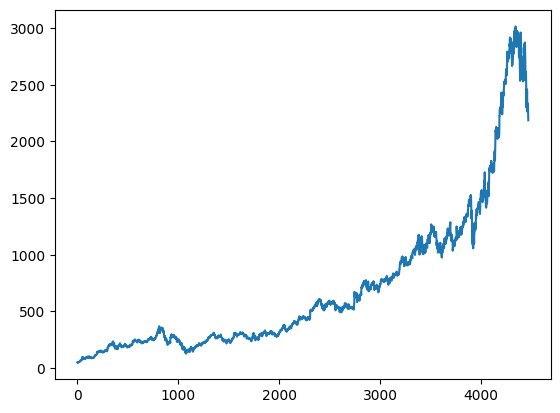

In [ ]:
# viz a single col
google['Close'].plot()

In [ ]:
google.loc['2016-10-13'] ['Close'].plot()

KeyError: '2016-10-13'

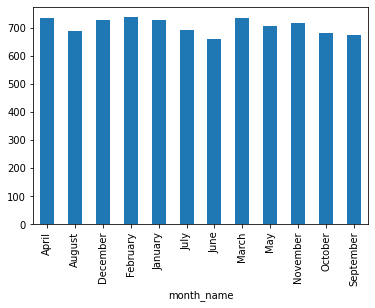

In [ ]:
google.groupby('month_name')['Close'].mean().plot(kind='bar')

In [ ]:
# frequency
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[ns]', name='Date', length=4632, freq='B')

In [ ]:
# asfreq
google.asfreq('6H',method='bfill')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-19 06:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-19 12:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-19 18:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0
2022-05-19 06:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100.0,May,Friday,2.0
2022-05-19 12:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100.0,May,Friday,2.0


### Resampling

Resampling involves changing the frequency of your time series observations.

Two types of resampling are:

**Upsampling**: Where you increase the frequency of the samples, such as from minutes to seconds.<br>
**Downsampling**: Where you decrease the frequency of the samples, such as from days to months.

In [ ]:
google.set_index('Date').head(2)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874


<Axes: >

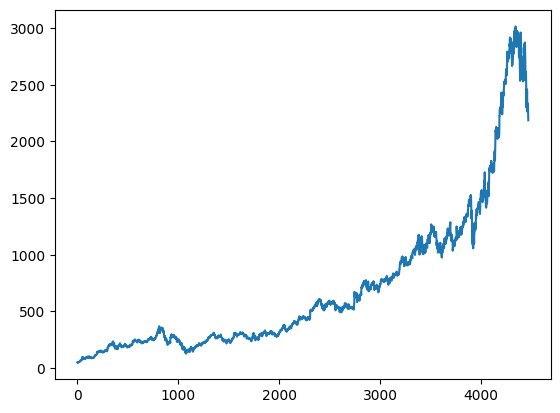

In [28]:
# Downsampling
google['Close'].plot()


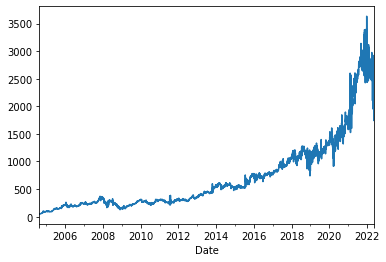

In [ ]:
# Upsampling
google['Close'].resample('12H').interpolate(method='spline',order=2).plot()

### Rolling Window(Smoothing)
Time series data in original format can be quite volatile, especially on smaller aggregation levels. The concept of rolling, or moving averages is a useful technique for smoothing time series data.

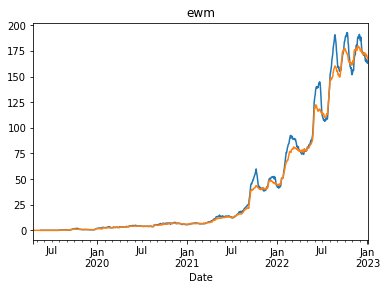

In [ ]:
# Rolling window
yt['Subscribers'].rolling(30).mean().plot(title='rolling')
yt['Subscribers'].ewm(30).mean().plot(title='ewm')


### Shifting

The shift() function is Pandas is used to, well, shift the entire series up or down by the desired number of periods.

In [ ]:
# shift
yt['Subscribers']

Date
2019-04-17      0
2019-04-18      0
2019-04-19      0
2019-04-20      0
2019-04-21      0
             ... 
2022-12-31    116
2023-01-01    142
2023-01-02    171
2023-01-03    162
2023-01-04    147
Name: Subscribers, Length: 1359, dtype: int64

In [ ]:
yt['Subscribers'].shift(-1)

Date
2019-04-17      0.0
2019-04-18      0.0
2019-04-19      0.0
2019-04-20      0.0
2019-04-21      0.0
              ...  
2022-12-31    142.0
2023-01-01    171.0
2023-01-02    162.0
2023-01-03    147.0
2023-01-04      NaN
Name: Subscribers, Length: 1359, dtype: float64

In [ ]:
# shift example
df = pd.read_csv('/content/login.csv',header=None)
df = df[[1,2]]
df.head()
df.rename(columns={1:'user_id',2:'login_time'},inplace=True)
df.head()

,user_id,login_time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59


In [ ]:
user_df = df[df['user_id'] == 458]
user_df.head()

,user_id,login_time
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
9,458,2017-01-09 11:13:12
10,458,2017-01-09 11:34:02
25,458,2017-01-10 12:14:11


In [ ]:
user_df['login_time'] = pd.to_datetime(user_df['login_time'])
user_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 208 entries, 2 to 1018
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     208 non-null    int64         
 1   login_time  208 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.9 KB


<ipython-input-269-fd41e73e6ce6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['login_time'] = pd.to_datetime(user_df['login_time'])


In [ ]:
user_df['shifted'] = user_df['login_time'].shift(1)
(user_df['login_time'] - user_df['shifted']).mean()

<ipython-input-270-091b95be4a6b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted'] = user_df['login_time'].shift(1)


Timedelta('0 days 17:29:22.053140096')

In [ ]:
ax = df.plot(subplots=True,
                    layout=(3, 2),
                     sharex=False,
                     sharey=False,
                     linewidth=0.7,
                     fontsize=10,
                     legend=False,
                      figsize=(20,15),
                      title=['Open', 'High', 'Low', 'Close','Adjusted Close', 'Volume'])